[[ 0.99950336  0.09899013]
 [-0.00989901  0.97970533]] [[0.00024832]
 [0.00494951]] [[1. 0.]] 0


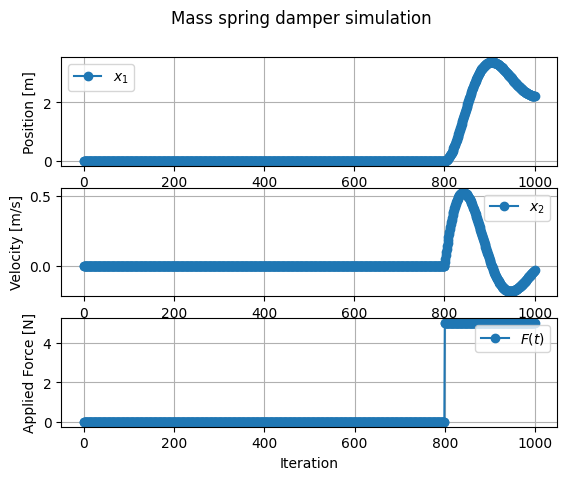

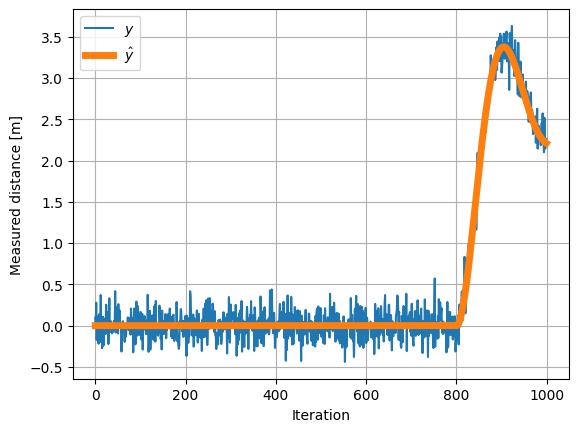

In [6]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt


b = 4.0  # Damping constant
k = 2.0  # Stiffness of the spring
m = 20.0  # Mass
# F = 5.0  # Force
Ac = np.array([[0.0, 1.0], [-k / m, -b / m]])
Bc = np.array([[0.0], [1.0 / m]])
Cc = np.array([[1.0, 0.0]])
Dc = 0

dt = 0.1  # seconds      

x0 = np.array([0.0, 0.0])
#x0 = np.array([-2.5, 0.25])
(Ad, Bd, Cd, Dd, _) = signal.cont2discrete((Ac, Bc, Cc, Dc), dt, method='zoh', alpha=None)

print(Ad, Bd, Cd, Dd)

Nsim = 1000

Nx = 2
Ny = 1
Nu = 1

Xsim = np.zeros((Nsim+1, Nx))
Ysim = np.zeros((Nsim, Ny))
Ymeas = np.zeros((Nsim, Ny))
Usim = np.ones((Nsim, Nu)) * 0.0
Usim[800:] = 5.0

Xsim[0, :] = x0
for k in range(Nsim):
    Xsim[k+1, :] = Ad @ Xsim[k, :] + Bd @ Usim[k, :]
    Ysim[k, :] = Cd @ Xsim[k, :]
    Ymeas[k, :] = Ysim[k, :] + np.random.randn(Ny) * 0.15

plt.figure()
plt.suptitle("Mass spring damper simulation")

plt.subplot(311)
plt.plot(Xsim[:, 0], label=r"$x_1$", marker='o')
plt.grid()
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Position [m]")

plt.subplot(312)
plt.plot(Xsim[:, 1], label=r"$x_2$", marker='o')
plt.grid()
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Velocity [m/s]")

plt.subplot(313)
plt.plot(Usim[:, 0], label=r"$F(t)$", marker='o')
plt.grid()
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Applied Force [N]")

plt.figure()
plt.plot(Ymeas, label=r"$y$")
plt.plot(Ysim, label=r"$\hat{y}$", alpha=1.0, linewidth=5.0)
plt.grid()
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Measured distance [m]")

plt.show()

In [7]:
np.savetxt("Ymeas.txt", Ymeas)